In [1]:
import numpy as np
import pandas as pd

import risk_kit as rk

%load_ext autoreload
%autoreload 2

Load the 30 Value Weighted industry portfolio returns. Limit the analysis to returns of the 30 VW portfolios from 1997 onwards (1997 included, 1996 not included, 2018 included). Also load the Market Caps of each of the 30 industries. Run a backtest of comparing a CapWeighted vs an EW portfolio over the period. Though these two weighting schemes do not need any estimation, use an estimation period of 36 months so that we can compare it in the next few questions. 

In [2]:
ind_30_vw = rk.get_ind_returns(weighting='vw', n_inds=30)
ind_30_vw.head()

,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
1926-07,0.0056,-0.0519,0.0129,0.0293,0.1097,-0.0048,0.0808,0.0177,0.0814,0.0039,...,0.0083,0.0922,0.0206,0.0770,0.0193,-0.2379,0.0007,0.0187,0.0037,0.0520
1926-08,0.0259,0.2703,0.0650,0.0055,0.1001,-0.0358,-0.0251,0.0425,0.0550,0.0814,...,0.0217,0.0202,0.0439,-0.0238,0.0488,0.0539,-0.0075,-0.0013,0.0446,0.0676
1926-09,0.0116,0.0402,0.0126,0.0658,-0.0099,0.0073,-0.0051,0.0069,0.0533,0.0231,...,0.0241,0.0225,0.0019,-0.0554,0.0005,-0.0787,0.0025,-0.0056,-0.0123,-0.0386
1926-10,-0.0306,-0.0331,0.0106,-0.0476,0.0947,-0.0468,0.0012,-0.0057,-0.0476,0.0100,...,-0.0011,-0.0200,-0.0109,-0.0508,-0.0264,-0.1538,-0.0220,-0.0411,-0.0516,-0.0849
1926-11,0.0635,0.0729,0.0455,0.0166,-0.0580,-0.0054,0.0187,0.0542,0.0520,0.0311,...,0.0163,0.0377,0.0364,0.0384,0.0160,0.0467,0.0652,0.0433,0.0224,0.0400


In [3]:
ind_30_vw_97_18 = ind_30_vw.loc['1997' : '2018']
mkt_cap_30 = rk.get_ind_market_caps(n_inds=30, weights=True)
mkt_cap_30_97_18 = mkt_cap_30.loc['1997' : '2018']

In [4]:
cwr = rk.backtest_ws(ind_30_vw_97_18, estimation_window = 36, weighting = rk.weight_cw, cap_weights = mkt_cap_30_97_18)
ewr = rk.backtest_ws(ind_30_vw_97_18, estimation_window = 36, weighting = rk.weight_ew)

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
EW,0.077614,0.158685,-0.538531,5.317042,0.072485,0.106220,0.291838,-0.53298
CW,0.065196,0.151478,-0.556621,4.249894,0.071076,0.098531,0.225949,-0.51899


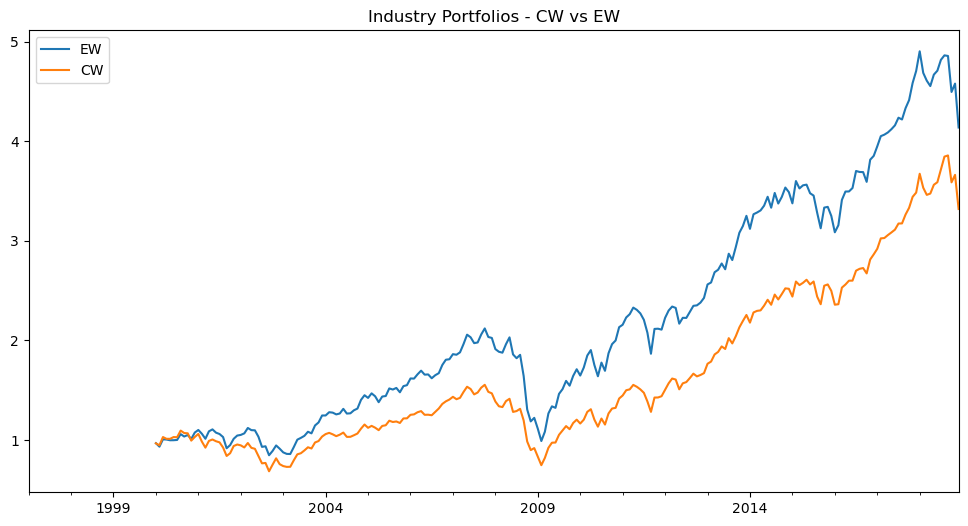

In [5]:
btr = pd.DataFrame({"EW": ewr, "CW": cwr})
(1+btr).cumprod().plot(figsize=(12,6), title="Industry Portfolios - CW vs EW")
rk.summary_stats(btr.dropna())

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
EW,0.077614,0.158685,-0.538531,5.317042,0.072485,0.106220,0.291838,-0.532980
CW,0.065196,0.151478,-0.556621,4.249894,0.071076,0.098531,0.225949,-0.518990
EW_thethered,0.076838,0.140774,-0.649872,4.664374,0.065482,0.093766,0.323653,-0.487413


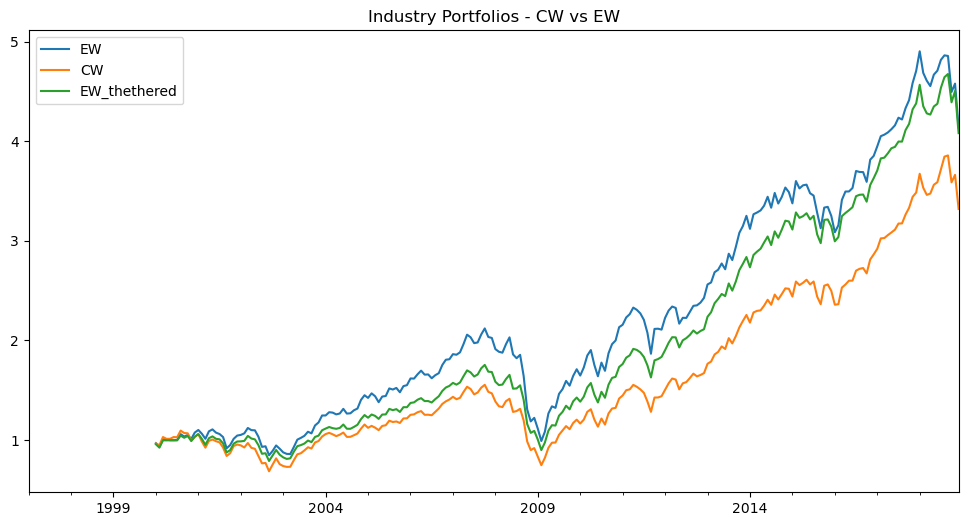

In [6]:
ewr_tethered = rk.backtest_ws(ind_30_vw_97_18,
                              cap_weights = mkt_cap_30_97_18, 
                              max_cw_mult = 2, 
                              microcap_threshold = 0.01,
                              estimation_window = 36)
btr['EW_thethered'] = ewr_tethered
(1+btr).cumprod().plot(figsize=(12,6), title="Industry Portfolios - CW vs EW")
rk.summary_stats(btr.dropna())

In [7]:
btr.dropna().head()

,EW,CW,EW_thethered
2000-01,-0.031137,-0.032905,-0.042504
2000-02,-0.036047,-0.019727,-0.035002
2000-03,0.078613,0.086877,0.079845
2000-04,-0.002040,-0.017218,-0.000779
2000-05,-0.007117,-0.000144,0.001206


In [8]:
tr = rk.tracking_error(ewr, cwr)
tr

np.float64(0.18752094143646486)

In [9]:
tr = rk.tracking_error(ewr_tethered, cwr)
tr

np.float64(0.11671015519949166)

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
EW,0.077614,0.158685,-0.538531,5.317042,0.072485,0.106220,0.291838,-0.532980
CW,0.065196,0.151478,-0.556621,4.249894,0.071076,0.098531,0.225949,-0.518990
EW_thethered,0.076838,0.140774,-0.649872,4.664374,0.065482,0.093766,0.323653,-0.487413
GMVR,0.066306,0.117410,-0.741087,4.469210,0.055456,0.080583,0.300815,-0.421289


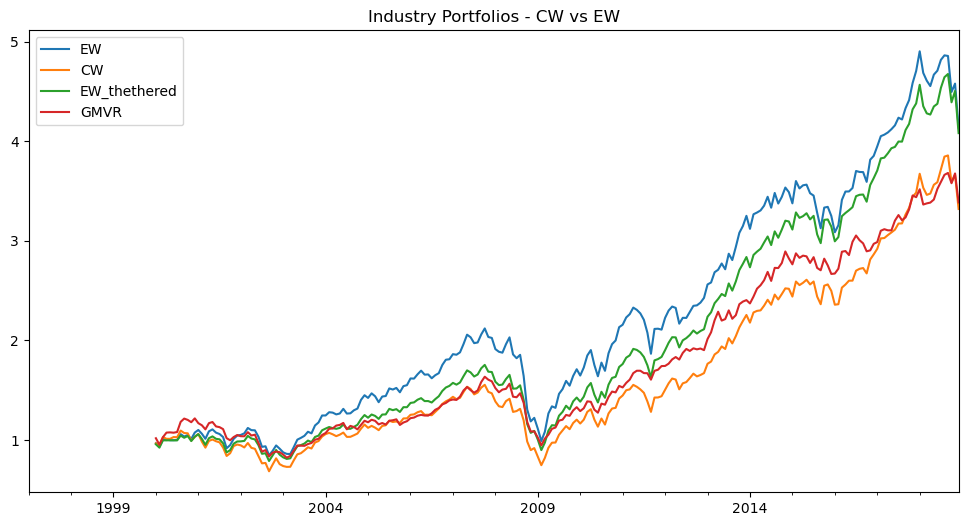

In [11]:
gmvr = rk.backtest_ws(ind_30_vw_97_18,
                      weighting = rk.weight_gmv,
                      estimation_window = 36)
btr['GMVR'] = gmvr
(1+btr).cumprod().plot(figsize=(12,6), title="Industry Portfolios - CW vs EW")
rk.summary_stats(btr.dropna())

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
EW,0.077614,0.158685,-0.538531,5.317042,0.072485,0.106220,0.291838,-0.532980
CW,0.065196,0.151478,-0.556621,4.249894,0.071076,0.098531,0.225949,-0.518990
EW_thethered,0.076838,0.140774,-0.649872,4.664374,0.065482,0.093766,0.323653,-0.487413
GMVR,0.068467,0.114572,-0.731298,4.264945,0.053884,0.077715,0.326635,-0.393410


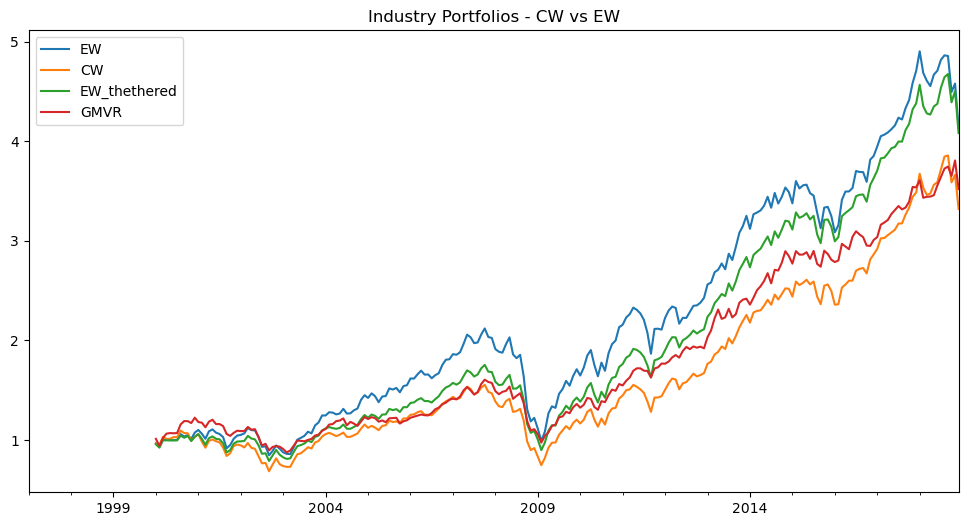

In [12]:
gmvr = rk.backtest_ws(ind_30_vw_97_18,
                      weighting = rk.weight_gmv,
                      cov_estimator = rk.shrinkage_cov,
                      delta=0.25,
                      estimation_window = 36)
btr['GMVR'] = gmvr
(1+btr).cumprod().plot(figsize=(12,6), title="Industry Portfolios - CW vs EW")
rk.summary_stats(btr.dropna())